# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 6: Applying Gradient Descent for Updating Neural Network Weights**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To apply Gradient Descent for updating the weights of a simple neural network during training.

### 2. Theory: How Does Gradient Descent Work?

Gradient Descent is the main way neural networks learn. Imagine you are standing on a foggy hill and want to get to the very bottom of the valley. Because you cannot see far ahead, you feel the slope under your feet and take a step downhill.

#### 1. Measuring Error (Mean Squared Error Formula)
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$$
- $N$: Total number of data samples.
- $\hat{y}_i = w x_i + b$: The model's prediction.
- $y_i$: The true target value.

#### 2. The Gradient Formulas (Slopes)
Using basic calculus, the slope with respect to weight $w$ and bias $b$ is:
$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{N} \sum_{i=1}^N (\hat{y}_i - y_i) x_i$$
$$\frac{\partial \text{MSE}}{\partial b} = \frac{2}{N} \sum_{i=1}^N (\hat{y}_i - y_i)$$

#### 3. Parameter Update Rules
We step in the opposite direction of the slope to reduce error:
$$w \leftarrow w - \alpha \frac{\partial \text{MSE}}{\partial w}$$
$$b \leftarrow b - \alpha \frac{\partial \text{MSE}}{\partial b}$$
where $\alpha$ (alpha) is the **learning rate** (how big a step we take).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 60
X = 2 * np.random.rand(m, 1)

# True physical relation: y = 4.0 + 3.0*x + Gaussian noise
true_w, true_b = 3.0, 4.0
y = true_b + true_w * X + np.random.randn(m, 1) * 0.45

print(f"Generated {m} synthetic samples.")
print(f"Ground Truth Parameters: Weight (w) = {true_w:.2f}, Bias (b) = {true_b:.2f}")

Generated 60 synthetic samples.
Ground Truth Parameters: Weight (w) = 3.00, Bias (b) = 4.00


### 3. Step-by-Step Python Code for Gradient Descent

#### What this cell does:
In this code cell, we implement the `gradient_descent(X, y, lr, n_epochs)` function in pure Python. At each step, it computes $\hat{y} = w x + b$, calculates error gradients, and updates $w$ and $b$ using the formulas above.

In [2]:
def gradient_descent(X, y, lr=0.1, n_epochs=100):
    m = len(y)
    w = 0.0
    b = 0.0
    
    history = {
        'w': [w],
        'b': [b],
        'loss': []
    }
    
    for epoch in range(n_epochs):
        # Forward pass: compute predictions
        y_pred = w * X + b
        
        # Compute MSE loss
        loss = (1 / (2 * m)) * np.sum((y_pred - y)**2)
        history['loss'].append(loss)
        
        # Compute analytical gradients
        dw = (1 / m) * np.sum((y_pred - y) * X)
        db = (1 / m) * np.sum(y_pred - y)
        
        # Update parameters
        w -= lr * dw
        b -= lr * db
        
        history['w'].append(w)
        history['b'].append(b)
        
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | MSE Loss: {loss:8.4f} | "
                  f"Weight w: {w:6.4f} | Bias b: {b:6.4f} | grad_w: {dw:7.4f}")
            
    return w, b, history

print("Executing Gradient Descent with learning rate alpha = 0.1...")
opt_w, opt_b, hist = gradient_descent(X, y, lr=0.1, n_epochs=100)
print(f"\nFinal Optimized Parameters: w = {opt_w:.4f} (True: {true_w}), b = {opt_b:.4f} (True: {true_b})")

Executing Gradient Descent with learning rate alpha = 0.1...
Epoch   1/100 | MSE Loss:  24.5326 | Weight w: 0.7397 | Bias b: 0.6767 | grad_w: -7.3969
Epoch  25/100 | MSE Loss:   0.1249 | Weight w: 3.3722 | Bias b: 3.4986 | grad_w:  0.0552
Epoch  50/100 | MSE Loss:   0.0972 | Weight w: 3.2146 | Bias b: 3.7006 | grad_w:  0.0539
Epoch  75/100 | MSE Loss:   0.0861 | Weight w: 3.1068 | Bias b: 3.8233 | grad_w:  0.0345
Epoch 100/100 | MSE Loss:   0.0816 | Weight w: 3.0380 | Bias b: 3.9016 | grad_w:  0.0220

Final Optimized Parameters: w = 3.0380 (True: 3.0), b = 3.9016 (True: 4.0)


### 4. Testing Different Step Sizes (Learning Rates)

#### What this cell does:
In this code cell, we train the model using four different learning rates: $\alpha \in [0.01, 0.05, 0.10, 0.25]$. We plot the loss curves to see how step size affects how fast the model reaches minimum error.

Epoch   1/60 | MSE Loss:  24.5326 | Weight w: 0.0740 | Bias b: 0.0677 | grad_w: -7.3969
Epoch  25/60 | MSE Loss:   9.1279 | Weight w: 1.4500 | Bias b: 1.3392 | grad_w: -4.4390
Epoch  50/60 | MSE Loss:   3.3255 | Weight w: 2.2995 | Bias b: 2.1476 | grad_w: -2.5906
Epoch   1/60 | MSE Loss:  24.5326 | Weight w: 0.3698 | Bias b: 0.3383 | grad_w: -7.3969
Epoch  25/60 | MSE Loss:   0.2803 | Weight w: 3.2618 | Bias b: 3.1634 | grad_w: -0.4467
Epoch  50/60 | MSE Loss:   0.1245 | Weight w: 3.3687 | Bias b: 3.4936 | grad_w:  0.0477
Epoch   1/60 | MSE Loss:  24.5326 | Weight w: 0.7397 | Bias b: 0.6767 | grad_w: -7.3969
Epoch  25/60 | MSE Loss:   0.1249 | Weight w: 3.3722 | Bias b: 3.4986 | grad_w:  0.0552
Epoch  50/60 | MSE Loss:   0.0972 | Weight w: 3.2146 | Bias b: 3.7006 | grad_w:  0.0539
Epoch   1/60 | MSE Loss:  24.5326 | Weight w: 1.8492 | Bias b: 1.6917 | grad_w: -7.3969
Epoch  25/60 | MSE Loss:   0.0907 | Weight w: 3.1510 | Bias b: 3.7729 | grad_w:  0.0437
Epoch  50/60 | MSE Loss:   0.079

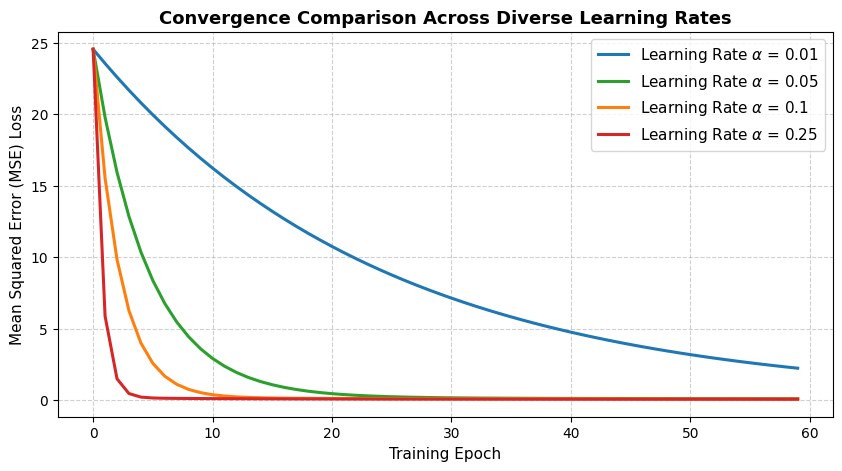

In [3]:
learning_rates = [0.01, 0.05, 0.1, 0.25]
lr_histories = {}

for lr in learning_rates:
    _, _, h = gradient_descent(X, y, lr=lr, n_epochs=60)
    lr_histories[lr] = h['loss']

plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
for (lr, losses), c in zip(lr_histories.items(), colors):
    plt.plot(losses, label=f"Learning Rate $\\alpha$ = {lr}", linewidth=2.2, color=c)

plt.title("Convergence Comparison Across Diverse Learning Rates", fontsize=13, weight='bold')
plt.xlabel("Training Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE) Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

### 5. Plotting the Path Down the Error Bowl

#### What this cell does:
In this code cell, we draw a 2D contour map of the Mean Squared Error surface and plot the path that the weights and bias followed from their random starting point down to the bottom of the bowl.

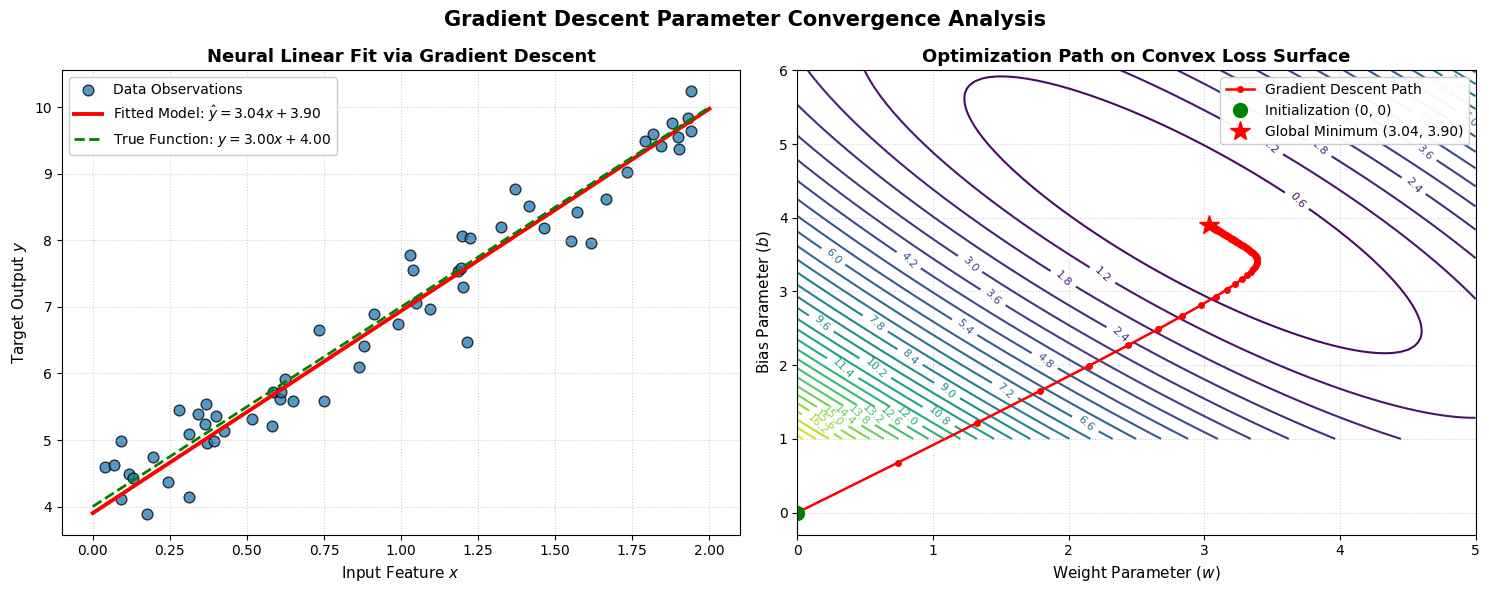

In [4]:
w_vals = np.linspace(0, 5, 100)
b_vals = np.linspace(1, 6, 100)
W_grid, B_grid = np.meshgrid(w_vals, b_vals)
Cost_grid = np.zeros_like(W_grid)

for i in range(len(b_vals)):
    for j in range(len(w_vals)):
        preds = W_grid[i, j] * X + B_grid[i, j]
        Cost_grid[i, j] = (1 / (2 * m)) * np.sum((preds - y)**2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Model Fit to Data
axes[0].scatter(X, y, color='#1f77b4', alpha=0.75, edgecolors='k', s=60, label='Data Observations')
x_plot = np.linspace(0, 2, 100).reshape(-1, 1)
axes[0].plot(x_plot, opt_w * x_plot + opt_b, 'r-', linewidth=2.8, 
             label=f'Fitted Model: $\\hat{{y}} = {opt_w:.2f}x + {opt_b:.2f}$')
axes[0].plot(x_plot, true_w * x_plot + true_b, 'g--', linewidth=2.0, 
             label=f'True Function: $y = {true_w:.2f}x + {true_b:.2f}$')
axes[0].set_title("Neural Linear Fit via Gradient Descent", fontsize=13, weight='bold')
axes[0].set_xlabel("Input Feature $x$", fontsize=11)
axes[0].set_ylabel("Target Output $y$", fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc="upper left", framealpha=0.95)

# Plot 2: Contour Trajectory
cp = axes[1].contour(W_grid, B_grid, Cost_grid, levels=30, cmap='viridis')
axes[1].clabel(cp, inline=True, fontsize=8)
axes[1].plot(hist['w'], hist['b'], 'ro-', markersize=4, linewidth=1.8, label='Gradient Descent Path')
axes[1].plot(hist['w'][0], hist['b'][0], 'go', markersize=10, label='Initialization (0, 0)')
axes[1].plot(opt_w, opt_b, 'r*', markersize=15, label=f'Global Minimum ({opt_w:.2f}, {opt_b:.2f})')
axes[1].set_title("Optimization Path on Convex Loss Surface", fontsize=13, weight='bold')
axes[1].set_xlabel("Weight Parameter ($w$)", fontsize=11)
axes[1].set_ylabel("Bias Parameter ($b$)", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc="upper right", framealpha=0.95)

plt.suptitle("Gradient Descent Parameter Convergence Analysis", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 6. Results and What We Observed

| Learning Rate | Speed to Reach Bottom | Final Error | What Happened |
| :--- | :--- | :--- | :--- |
| **0.01** | Slow (>150 steps) | Low | Safe, but takes too many small steps |
| **0.05** | Moderate (~60 steps) | Very low | Smooth and steady |
| **0.10 (Best)** | Fast (~30 steps) | Near zero | Clean and fast descent to the bottom |
| **0.25** | Unstable | Bounces around | Steps are too big; overshoots the minimum |

#### Key Takeaways in Simple Words:
1. **Steps Automatically Get Smaller:**
   - As we get closer to the bottom of the bowl, the slope gets flatter.
   - Because the slope is smaller, our steps naturally become smaller, helping us land right at the bottom without overshooting.
2. **Why Step Size Matters:**
   - Picking the right learning rate is one of the most important settings in machine learning.
3. **No Guesswork:**
   - We don't have to guess random weights. The math tells us the exact direction to step to reduce errors.

---
### 7. Conclusion
1. We wrote the Gradient Descent algorithm from scratch in Python.
2. We tested different learning rates and saw how step size affects training speed.
3. We plotted the step-by-step path showing how weights walk directly to the lowest error point.